In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel('Student_Admission_Records.xlsx')
data

,Student_ID,Student_Name,Gender,Age,Course_Applied,Previous_Percentage,Entrance_Exam_Score,Admission_Status,Fee_Status,Admission_Date
0,STU1001,Pranav Nair,Male,20,Medical Sciences,79.68,45,Pending,Unpaid,NaN
1,STU1002,Vivek Singh,Male,18,Mass Communication,78.17,48,Pending,Unpaid,NaN
2,STU1003,Harsh Agarwal,Male,19,Business Administration,77.95,78,Confirmed,Paid,08-Sep-2024
3,STU1004,Rishi Soni,Male,20,Economics,68.56,82,Pending,Unpaid,NaN
4,STU1005,Dhruv Banerjee,Male,24,Mechanical Engineering,65.78,44,Pending,Unpaid,NaN
...,...,...,...,...,...,...,...,...,...,...
95,STU1096,Anjali Malhotra,Female,21,Business Administration,65.03,86,Confirmed,Paid,07-Sep-2024
96,STU1097,Sachin Reddy,Male,19,Electronics & Communication,64.41,70,Pending,Unpaid,NaN
97,STU1098,Dev Chauhan,Male,21,Mechanical Engineering,91.22,58,Confirmed,Paid,02-Jul-2024
98,STU1099,Komal Jain,Female,19,Business Administration,56.98,43,Rejected,Unpaid,NaN


In [3]:
data.head()

,Student_ID,Student_Name,Gender,Age,Course_Applied,Previous_Percentage,Entrance_Exam_Score,Admission_Status,Fee_Status,Admission_Date
0,STU1001,Pranav Nair,Male,20,Medical Sciences,79.68,45,Pending,Unpaid,NaN
1,STU1002,Vivek Singh,Male,18,Mass Communication,78.17,48,Pending,Unpaid,NaN
2,STU1003,Harsh Agarwal,Male,19,Business Administration,77.95,78,Confirmed,Paid,08-Sep-2024
3,STU1004,Rishi Soni,Male,20,Economics,68.56,82,Pending,Unpaid,NaN
4,STU1005,Dhruv Banerjee,Male,24,Mechanical Engineering,65.78,44,Pending,Unpaid,NaN


In [4]:
data.describe()

,Age,Previous_Percentage,Entrance_Exam_Score
count,100.000000,100.000000,100.000000
mean,20.590000,77.629400,70.360000
std,2.202363,12.698166,17.271171
min,17.000000,55.260000,40.000000
25%,19.000000,65.772500,56.750000
50%,21.000000,78.505000,71.000000
75%,23.000000,88.035000,83.250000
max,24.000000,98.350000,100.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Student_ID           100 non-null    object 
 1   Student_Name         100 non-null    object 
 2   Gender               100 non-null    object 
 3   Age                  100 non-null    int64  
 4   Course_Applied       100 non-null    object 
 5   Previous_Percentage  100 non-null    float64
 6   Entrance_Exam_Score  100 non-null    int64  
 7   Admission_Status     100 non-null    object 
 8   Fee_Status           100 non-null    object 
 9   Admission_Date       39 non-null     object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.9+ KB


In [7]:
data.shape

(100, 10)

In [8]:
data.isnull().sum()

Student_ID              0
Student_Name            0
Gender                  0
Age                     0
Course_Applied          0
Previous_Percentage     0
Entrance_Exam_Score     0
Admission_Status        0
Fee_Status              0
Admission_Date         61
dtype: int64

In [9]:
data.fillna(0,inplace=True)

In [10]:
data.isnull().sum()

Student_ID             0
Student_Name           0
Gender                 0
Age                    0
Course_Applied         0
Previous_Percentage    0
Entrance_Exam_Score    0
Admission_Status       0
Fee_Status             0
Admission_Date         0
dtype: int64

In [11]:
data.drop_duplicates(inplace=True)

In [13]:
data['Admission_Date']=pd.to_datetime(data['Admission_Date'])

In [14]:
data['Gender']=data['Gender'].str.upper()

In [15]:
data['Admission_Status'].value_counts()

Admission_Status
Confirmed    39
Pending      37
Rejected     24
Name: count, dtype: int64

In [16]:
data['Gender'].value_counts()

Gender
MALE      55
FEMALE    40
OTHER      5
Name: count, dtype: int64

In [17]:
data.groupby('Course_Applied')['Student_ID'].count()

Course_Applied
Architecture                    6
Biotechnology                   7
Business Administration         8
Chemical Engineering            8
Civil Engineering               7
Computer Science                5
Data Science                    7
Economics                       6
Electronics & Communication    10
Information Technology          3
Law                             3
Mass Communication              7
Mechanical Engineering          6
Medical Sciences                9
Psychology                      8
Name: Student_ID, dtype: int64

In [22]:
data.groupby('Student_ID')['Entrance_Exam_Score'].mean().head()

Student_ID
STU1001    45.0
STU1002    48.0
STU1003    78.0
STU1004    82.0
STU1005    44.0
Name: Entrance_Exam_Score, dtype: float64

In [24]:
data.groupby('Course_Applied')['Entrance_Exam_Score'].mean()

Course_Applied
Architecture                   78.666667
Biotechnology                  65.142857
Business Administration        79.875000
Chemical Engineering           67.625000
Civil Engineering              63.000000
Computer Science               61.400000
Data Science                   67.571429
Economics                      64.166667
Electronics & Communication    75.700000
Information Technology         85.000000
Law                            56.000000
Mass Communication             68.142857
Mechanical Engineering         62.833333
Medical Sciences               80.777778
Psychology                     70.125000
Name: Entrance_Exam_Score, dtype: float64

Text(0, 0.5, 'Count')

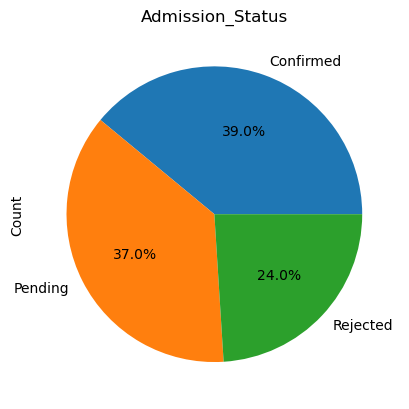

In [27]:
data['Admission_Status'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Admission_Status')
plt.ylabel('Count')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Medical Sciences'),
  Text(1, 0, 'Mass Communication'),
  Text(2, 0, 'Business Administration'),
  Text(3, 0, 'Economics'),
  Text(4, 0, 'Mechanical Engineering'),
  Text(5, 0, 'Chemical Engineering'),
  Text(6, 0, 'Electronics & Communication'),
  Text(7, 0, 'Information Technology'),
  Text(8, 0, 'Data Science'),
  Text(9, 0, 'Psychology'),
  Text(10, 0, 'Civil Engineering'),
  Text(11, 0, 'Architecture'),
  Text(12, 0, 'Law'),
  Text(13, 0, 'Computer Science'),
  Text(14, 0, 'Biotechnology')])

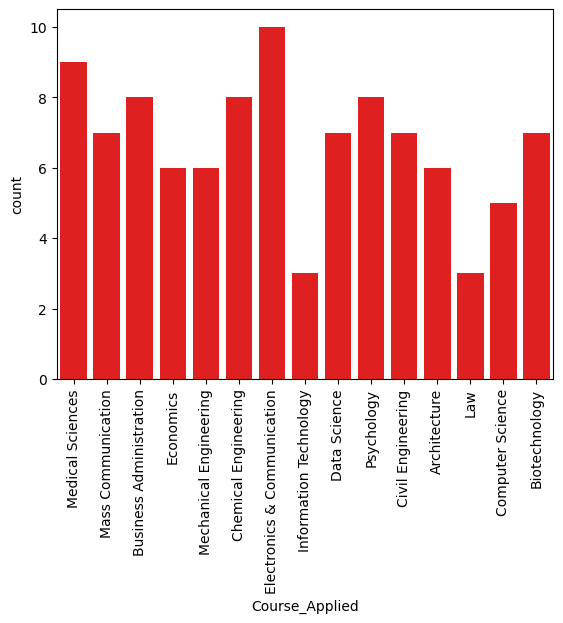

In [34]:
sns.countplot(x='Course_Applied',data=data,color='red')
plt.xticks(rotation=90)

<Axes: xlabel='Admission_Date'>

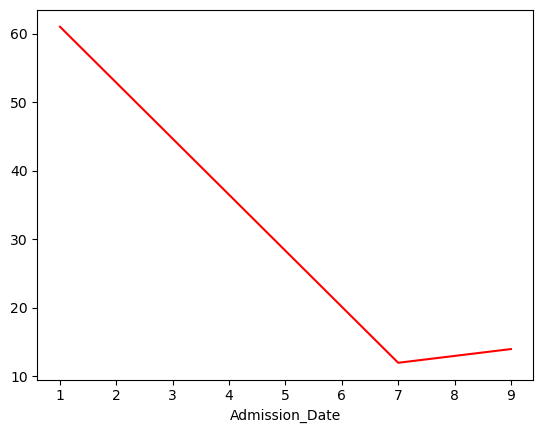

In [35]:
monthly=data.groupby(data['Admission_Date'].dt.month)['Student_ID'].count()
monthly.plot(kind='line',color='red')

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14., 16.]),
 [Text(-2.0, 0, 'Medical Sciences'),
  Text(0.0, 0, 'Architecture'),
  Text(2.0, 0, 'Business Administration'),
  Text(4.0, 0, 'Civil Engineering'),
  Text(6.0, 0, 'Data Science'),
  Text(8.0, 0, 'Electronics & Communication'),
  Text(10.0, 0, 'Law'),
  Text(12.0, 0, 'Mechanical Engineering'),
  Text(14.0, 0, 'Psychology'),
  Text(16.0, 0, '')])

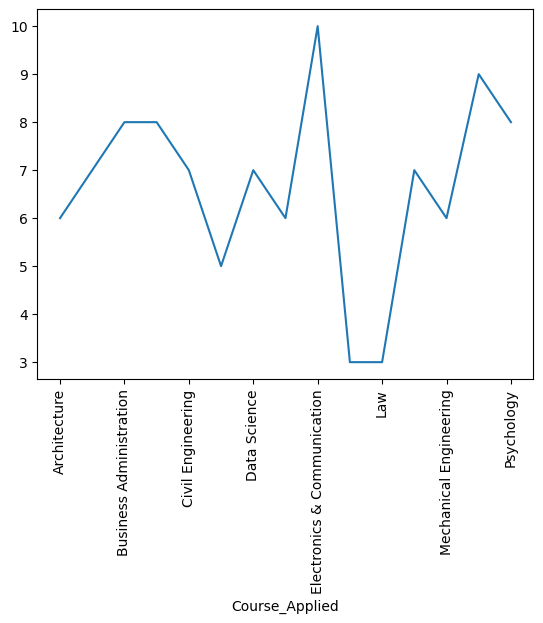

In [37]:
Coures=data.groupby('Course_Applied')['Student_ID'].count()
Coures.plot(kind='line')
plt.xticks(rotation=90)